EDA
Listing Columns, missing values 

In [1]:
import pandas as pd 
pd.set_option('display.max_colwidth',80)

df = pd.read_csv("../data/reviews.csv", low_memory=False)

print("Shape:",df.shape)
print("\n Columns:",list(df.columns))
print("\n Missing Values\n",df.isnull().sum().sort_values(ascending=False).head(10))

Shape: (34660, 21)

 Columns: ['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']

 Missing Values
 reviews.userCity        34660
reviews.userProvince    34660
reviews.id              34659
reviews.didPurchase     34659
reviews.dateAdded       10621
name                     6760
reviews.doRecommend       594
reviews.numHelpful        529
reviews.date               39
reviews.rating             33
dtype: int64


Handling missing reviews before text operations

In [2]:
df['reviews.text'] = df['reviews.text'].fillna('')
#rate distribution class imbalance check
print(df['reviews.rating'].value_counts().sort_index())

#date range
df['review.date'] = pd.to_datetime(df['reviews.date'],errors = 'coerce')
print(df['reviews.date'].min(),"to", df['reviews.date'].max())

#Length inwords 
df['review_word_count'] = df['reviews.text'].apply(lambda x: len(str(x).split()))
print(df['review_word_count'].describe())

reviews.rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23775
Name: count, dtype: int64
2010-07-09T00:00:00Z to 2018-04-18T00:00:00.000Z
count    34660.000000
mean        30.403289
std         34.641440
min          0.000000
25%         13.000000
50%         21.000000
75%         35.000000
max       1858.000000
Name: review_word_count, dtype: float64


VISUALIZATION
Rating Distribution and Review Lengths

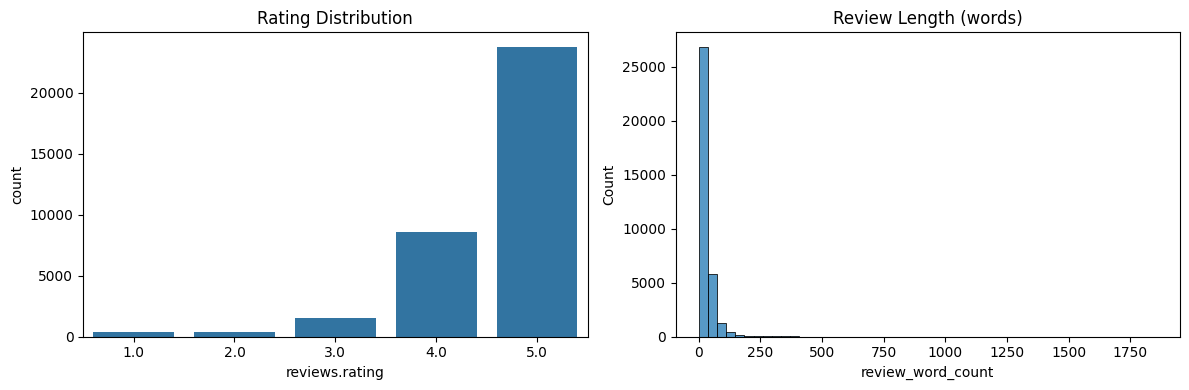

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='reviews.rating', data=df, ax=axes[0])
axes[0].set_title('Rating Distribution')

sns.histplot(df['review_word_count'], bins=50, ax=axes[1])
axes[1].set_title('Review Length (words)')
plt.tight_layout()
plt.show()

Tokenization

In [4]:
import spacy

nlp = spacy.load("en_core_web_sm")

# quick test
doc = nlp("The battery life is amazing but the screen isn't great!")
for token in doc:
    print(token.text, "->", token.lemma_, "| stopword:", token.is_stop)

The -> the | stopword: True
battery -> battery | stopword: False
life -> life | stopword: False
is -> be | stopword: True
amazing -> amazing | stopword: False
but -> but | stopword: True
the -> the | stopword: True
screen -> screen | stopword: False
is -> be | stopword: True
n't -> not | stopword: True
great -> great | stopword: False
! -> ! | stopword: False


In [5]:
def preprocess_text(doc):
    """Clean a spaCy doc: lowercase, remove stopwords/punctuation, lemmatize."""
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop        # remove stopwords
        and not token.is_punct      # remove punctuation
        and not token.is_space      # remove whitespace tokens
        and token.is_alpha          # keep only alphabetic tokens (drops numbers, symbols)
    ]
    return " ".join(tokens)

# quick test on the same sentence
test_doc = nlp("The battery life is amazing but the screen isn't great!")
print(preprocess_text(test_doc))

battery life amazing screen great


In [6]:
import time

texts = df['reviews.text'].tolist()

start = time.time()
cleaned_texts = [preprocess_text(doc) for doc in nlp.pipe(texts, batch_size=100)]
print(f"Processed {len(texts)} reviews in {time.time() - start:.1f} seconds")

df['cleaned_text'] = cleaned_texts
df[['reviews.text', 'cleaned_text']].head(5)

Processed 34660 reviews in 585.3 seconds


,reviews.text,cleaned_text
0,This product so far has not disappointed. My children love to use it and I l...,product far disappoint child love use like ability monitor control content ease
1,great for beginner or experienced person. Bought as a gift and she loves it,great beginner experienced person buy gift love
2,"Inexpensive tablet for him to use and learn on, step up from the NABI. He wa...",inexpensive tablet use learn step nabi thrill learn skype
3,I've had my Fire HD 8 two weeks now and I love it. This tablet is a great va...,fire hd week love tablet great value prime members tablet shines love able e...
4,I bought this for my grand daughter when she comes over to visit. I set it u...,buy grand daughter come visit set user enter age amazon make sure access sit...


In [7]:
# Words we want to KEEP even though spaCy marks them as stopwords
negation_words = {"not", "no", "never", "n't", "none", "nobody", "nothing", "neither", "nowhere"}

def preprocess_text(doc):
    tokens = [
        token.lemma_.lower()
        for token in doc
        if (not token.is_stop or token.lower_ in negation_words)
        and not token.is_punct
        and not token.is_space
        and (token.is_alpha or token.lower_ in negation_words)
    ]
    return " ".join(tokens)

# retest
test_doc = nlp("This product so far has not disappointed.")
print(preprocess_text(test_doc))

product far not disappoint


In [8]:
import time

start = time.time()
cleaned_texts = [preprocess_text(doc) for doc in nlp.pipe(texts, batch_size=100)]
print(f"Processed {len(texts)} reviews in {time.time() - start:.1f} seconds")

df['cleaned_text'] = cleaned_texts
df[['reviews.text', 'cleaned_text']].head(5)

Processed 34660 reviews in 723.7 seconds


,reviews.text,cleaned_text
0,This product so far has not disappointed. My children love to use it and I l...,product far not disappoint child love use like ability monitor control conte...
1,great for beginner or experienced person. Bought as a gift and she loves it,great beginner experienced person buy gift love
2,"Inexpensive tablet for him to use and learn on, step up from the NABI. He wa...",inexpensive tablet use learn step nabi thrill learn skype
3,I've had my Fire HD 8 two weeks now and I love it. This tablet is a great va...,fire hd week love tablet great value prime members tablet shines love able e...
4,I bought this for my grand daughter when she comes over to visit. I set it u...,buy grand daughter come visit set user enter age amazon make sure access sit...


In [9]:
df.to_csv("../data/reviews_cleaned.csv", index=False)
print("Saved!")

Saved!


In [10]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df = df.dropna(subset=['reviews.rating'])  # drop the 33 rows with missing rating
df['sentiment'] = df['reviews.rating'].apply(rating_to_sentiment)

print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True) * 100)

sentiment
positive    32316
neutral      1499
negative      812
Name: count, dtype: int64
sentiment
positive    93.326017
neutral      4.328992
negative     2.344991
Name: proportion, dtype: float64


In [11]:
from transformers import pipeline

sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# quick test
print(sentiment_pipeline("This product so far has not disappointed."))
print(sentiment_pipeline("Terrible battery life, very disappointed."))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9980061650276184}]
[{'label': 'NEGATIVE', 'score': 0.9997650980949402}]


Random Testing for 500 reviews

In [12]:
import pandas as pd

# take a random sample of 500 reviews for now
sample_df = df.sample(500, random_state=42).copy()

# transformers pipeline truncates automatically, but let's be safe with long reviews
def get_pretrained_sentiment(text):
    result = sentiment_pipeline(text[:512])[0]  # truncate to avoid errors on very long reviews
    return result['label'].lower()

sample_df['pretrained_sentiment'] = sample_df['reviews.text'].apply(get_pretrained_sentiment)

sample_df[['reviews.text', 'reviews.rating', 'sentiment', 'pretrained_sentiment']].head(10)

,reviews.text,reviews.rating,sentiment,pretrained_sentiment
34642,I bought this for myself because i play my kindle long periods of time and n...,5.0,positive,positive
8315,"My daughter is away at school, and she uses this inexpensive Amazon tablet, ...",5.0,positive,positive
11286,Bought this tablet for kids. Great price for what you get. Not as nice as th...,5.0,positive,positive
30128,Great little device to save money. Streams live and on demand TV. Great way ...,4.0,positive,negative
28520,I have wanted Echo ever since it came out. I ordered it off of amazon and th...,5.0,positive,negative
3470,like the firs one that folds in prongs better,5.0,positive,negative
21960,I love asking Alexa questions and getting the answers quickly. Music is unli...,5.0,positive,positive
10529,The graphic display is vibrant and just the right size. It is easy to read a...,5.0,positive,positive
25053,"Echo is a great , it can answer all questions and issues you may have . Grea...",5.0,positive,positive
8439,"I have one that I love so that I purchased this to give as a gift, and the r...",5.0,positive,positive


In [13]:
# Overall agreement rate (only compare non-neutral, since pretrained has no neutral class)
comparable = sample_df[sample_df['sentiment'] != 'neutral'].copy()
comparable['match'] = comparable['sentiment'] == comparable['pretrained_sentiment']
print("Agreement rate:", comparable['match'].mean())

print("\nMismatch examples:")
mismatches = comparable[~comparable['match']]
for i, row in mismatches.head(5).iterrows():
    print(f"\nRating: {row['reviews.rating']} | Derived: {row['sentiment']} | Pretrained: {row['pretrained_sentiment']}")
    print(f"Text: {row['reviews.text']}")

Agreement rate: 0.8773388773388774

Mismatch examples:

Rating: 4.0 | Derived: positive | Pretrained: negative
Text: Great little device to save money. Streams live and on demand TV. Great way to save money on TV subscriptions

Rating: 5.0 | Derived: positive | Pretrained: negative
Text: I have wanted Echo ever since it came out. I ordered it off of amazon and they kept saying it was on the wait list. Walked into Best Buy and it was on the shelve in the store. Grabbed one and it was worth the wait. When I got home called Amazon and cancelled my order.

Rating: 5.0 | Derived: positive | Pretrained: negative
Text: like the firs one that folds in prongs better

Rating: 4.0 | Derived: positive | Pretrained: negative
Text: I wish echo could play music (at the same time with the same song)to other dots in the house

Rating: 4.0 | Derived: positive | Pretrained: negative
Text: My first real tablet. It works awesome for books and playing movies. Even though it is limited to only amazon apps it

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df['cleaned_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train), "| Test size:", len(X_test))
print(y_train.value_counts())

Train size: 27701 | Test size: 6926
sentiment
positive    25852
neutral      1199
negative      650
Name: count, dtype: int64


Text to Vector Conversion

In [15]:
# Convert text to TF-IDF vectors
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF matrix shape:", X_train_tfidf.shape)

# Train Logistic Regression, with class_weight='balanced' to address the imbalance
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

TF-IDF matrix shape: (27701, 5000)
              precision    recall  f1-score   support

    negative       0.25      0.58      0.35       162
     neutral       0.16      0.45      0.24       300
    positive       0.98      0.87      0.92      6464

    accuracy                           0.84      6926
   macro avg       0.46      0.63      0.50      6926
weighted avg       0.93      0.84      0.88      6926



In [16]:
# Split cleaned_text back into token lists
df['tokens'] = df['cleaned_text'].apply(lambda x: x.split())

# Filter out empty token lists (some reviews may have become empty after cleaning)
df_topics = df[df['tokens'].apply(len) > 0].copy()
print(f"Reviews with usable tokens: {len(df_topics)} out of {len(df)}")

print(df_topics['tokens'].head(3))

Reviews with usable tokens: 34619 out of 34627
0    [product, far, not, disappoint, child, love, use, like, ability, monitor, co...
1                            [great, beginner, experienced, person, buy, gift, love]
2                [inexpensive, tablet, use, learn, step, nabi, thrill, learn, skype]
Name: tokens, dtype: object


In [17]:
from gensim import corpora

# Dictionary: maps each unique word to an integer ID
dictionary = corpora.Dictionary(df_topics['tokens'])

# Filter extremes: remove words that are too rare (noise) or too common (uninformative)
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Corpus: convert each review into a bag-of-words representation using that dictionary
corpus = [dictionary.doc2bow(tokens) for tokens in df_topics['tokens']]

print("Vocabulary size after filtering:", len(dictionary))
print("Example bag-of-words (first review):", corpus[0][:10])

Vocabulary size after filtering: 3211
Example bag-of-words (first review): [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1)]


In [18]:
from gensim.models import LdaModel

# num_topics is a hyperparameter we choose — let's start with 8 and see what comes out
num_topics = 8

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,          # how many times the model iterates over the full corpus
    alpha='auto',       # let gensim learn topic distribution priors automatically
    per_word_topics=True
)

# Print the top words for each discovered topic
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx}: {topic}\n")

Topic 0: 0.136*"love" + 0.091*"buy" + 0.037*"watch" + 0.036*"purchase" + 0.035*"movie" + 0.024*"enjoy" + 0.022*"kid" + 0.022*"game"

Topic 1: 0.114*"control" + 0.047*"memory" + 0.025*"subscription" + 0.025*"card" + 0.023*"soon" + 0.020*"storage" + 0.020*"thermostat" + 0.019*"sd"

Topic 2: 0.124*"kindle" + 0.036*"light" + 0.034*"new" + 0.026*"cover" + 0.025*"upgrade" + 0.020*"paperwhite" + 0.020*"read" + 0.017*"screen"

Topic 3: 0.048*"alexa" + 0.047*"app" + 0.043*"music" + 0.030*"amazon" + 0.024*"home" + 0.023*"device" + 0.023*"play" + 0.019*"ask"

Topic 4: 0.167*"tv" + 0.136*"fire" + 0.080*"amazon" + 0.050*"box" + 0.046*"stick" + 0.037*"prime" + 0.030*"streaming" + 0.021*"apple"

Topic 5: 0.124*"not" + 0.031*"cable" + 0.029*"no" + 0.020*"time" + 0.018*"like" + 0.017*"device" + 0.016*"want" + 0.014*"work"

Topic 6: 0.115*"great" + 0.064*"good" + 0.051*"product" + 0.050*"work" + 0.039*"echo" + 0.028*"recommend" + 0.024*"tablet" + 0.023*"price"

Topic 7: 0.150*"use" + 0.135*"easy" + 0.03

Coherence Score

In [ ]:
from gensim.models import CoherenceModel

topic_range = range(4, 13, 2)  # test 4, 6, 8, 10, 12
coherence_scores = []

for k in topic_range:
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha='auto'
    )
    coherence_model = CoherenceModel(
        model=model, texts=df_topics['tokens'], dictionary=dictionary, coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"num_topics={k} | coherence={score:.4f}")

LDA Coherence V/S Topic Count

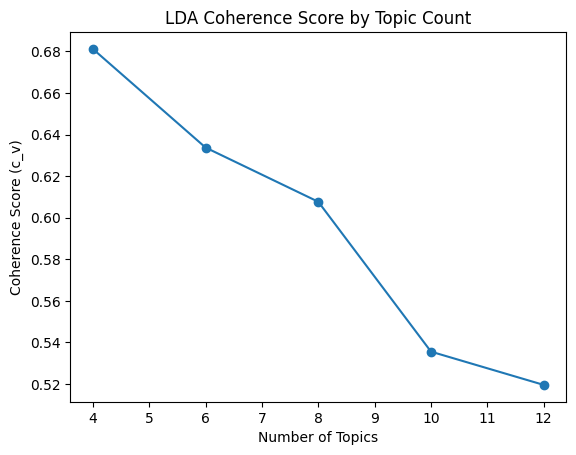

In [ ]:
import matplotlib.pyplot as plt

plt.plot(list(topic_range), coherence_scores, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("LDA Coherence Score by Topic Count")
plt.show()

num_topics=2 | coherence=0.4731
num_topics=3 | coherence=0.6594
num_topics=4 | coherence=0.6812
num_topics=5 | coherence=0.6446
num_topics=6 | coherence=0.6338
num_topics=7 | coherence=0.6064
num_topics=8 | coherence=0.6077
num_topics=9 | coherence=0.5843
num_topics=10 | coherence=0.5355
num_topics=11 | coherence=0.5515
num_topics=12 | coherence=0.5195


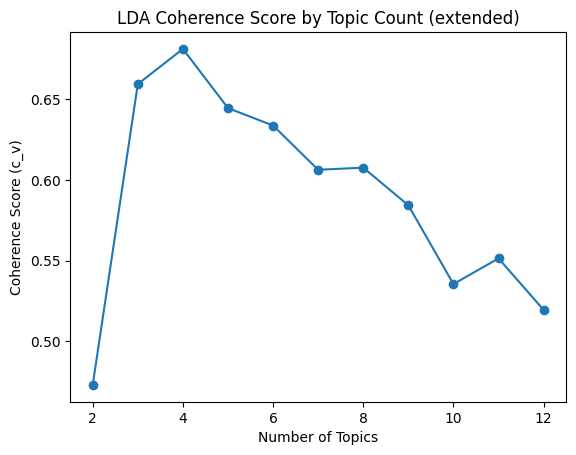

In [ ]:
topic_range_extended = range(2, 13, 1)  # test every value from 2 to 12
coherence_scores_extended = []

for k in topic_range_extended:
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha='auto'
    )
    coherence_model = CoherenceModel(
        model=model, texts=df_topics['tokens'], dictionary=dictionary, coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores_extended.append(score)
    print(f"num_topics={k} | coherence={score:.4f}")

plt.plot(list(topic_range_extended), coherence_scores_extended, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("LDA Coherence Score by Topic Count (extended)")
plt.show()

In [ ]:
lda_final = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

for idx, topic in lda_final.print_topics(num_words=10):
    print(f"Topic {idx}: {topic}\n")

Topic 0: 0.087*"great" + 0.071*"love" + 0.058*"use" + 0.054*"easy" + 0.044*"buy" + 0.035*"product" + 0.028*"good" + 0.024*"tablet" + 0.022*"recommend" + 0.020*"purchase"

Topic 1: 0.050*"alexa" + 0.049*"echo" + 0.044*"music" + 0.025*"home" + 0.023*"voice" + 0.019*"ask" + 0.018*"play" + 0.018*"speaker" + 0.017*"sound" + 0.014*"question"

Topic 2: 0.069*"kindle" + 0.048*"read" + 0.030*"book" + 0.023*"screen" + 0.021*"light" + 0.016*"battery" + 0.016*"not" + 0.014*"cover" + 0.013*"charge" + 0.012*"like"

Topic 3: 0.045*"not" + 0.044*"tv" + 0.036*"fire" + 0.035*"amazon" + 0.018*"work" + 0.017*"app" + 0.016*"device" + 0.013*"box" + 0.012*"stick" + 0.012*"fast"



Visualization LDA

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_final, corpus, dictionary)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.113458 -0.064937       1        1  36.523089
0     -0.103856 -0.284032       2        1  34.105450
2      0.260057  0.135869       3        1  16.242877
1     -0.269659  0.213101       4        1  13.128585, topic_info=       Term          Freq         Total Category  logprob  loglift
17    great  14025.000000  14025.000000  Default  30.0000  30.0000
8      love  11147.000000  11147.000000  Default  29.0000  29.0000
127  kindle   5118.000000   5118.000000  Default  28.0000  28.0000
114    easy   8870.000000   8870.000000  Default  27.0000  27.0000
361      tv   7451.000000   7451.000000  Default  26.0000  26.0000
..      ...           ...           ...      ...      ...      ...
840    turn    419.079189    901.560718   Topic4  -4.9701   1.2643
108   light    566.146430   2100.807770   Topic4  -4.6693   0.7192
85      set    604.767314   2835.543240   Topic4  -4.6033   0.4852
123  device    496.691535   3232.486627   Topic4  -4.8002   0.1573
7      like    449.503745   4255.706453   Topic4  -4.9000  -0.2175

[231 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
662       2  0.997489  absolutely
662       3  0.001744  absolutely
590       1  0.542313         add
590       4  0.456350         add
561       2  0.990610       adult
...     ...       ...         ...
112       1  0.994870       worth
112       3  0.003861       worth
105       2  0.948898        year
105       3  0.051081        year
444       2  0.994650       young

[317 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 3, 2])

BERT Model

In [ ]:
from bertopic import BERTopic

# BERTopic works on raw-ish text strings, list of documents
docs = df_topics['cleaned_text'].tolist()

topic_model = BERTopic(language="english", calculate_probabilities=False, verbose=True)
topics, probs = topic_model.fit_transform(docs)

# See what topics it found automatically (BERTopic decides the count itself, unlike LDA)
print(topic_model.get_topic_info().head(15))

2026-07-29 15:18:06,658 - BERTopic - Embedding - Transforming documents to embeddings.
c:\Users\mridh\AppData\Local\Programs\Python\Python311\Lib\site-packages\bertopic\backend\_sentencetransformers.py:4: DeprecationWarning: Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.
  from sentence_transformers.models import StaticEmbedding


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1082 [00:00<?, ?it/s]

2026-07-29 15:20:21,859 - BERTopic - Embedding - Completed ✓
2026-07-29 15:20:21,861 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-29 15:21:06,755 - BERTopic - Dimensionality - Completed ✓
2026-07-29 15:21:06,762 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-29 15:21:13,073 - BERTopic - Cluster - Completed ✓
2026-07-29 15:21:13,082 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-29 15:21:13,509 - BERTopic - Representation - Completed ✓


    Topic  Count                                 Name  \
0      -1  14422           -1_tablet_read_book_kindle   
1       0   5798           0_echo_alexa_music_speaker   
2       1    407    1_gift_christmas_recipient_person   
3       2    373  2_paperwhite_backlight_kindle_light   
4       3    360          3_game_play_educational_son   
5       4    279      4_price_tablet_value_affordable   
6       5    267             5_memory_card_sd_storage   
7       6    251      6_christmas_gift_tablet_present   
8       7    247             7_fire_tablet_amazon_tab   
9       8    219               8_game_play_son_tablet   
10      9    199            9_light_night_bright_dark   
11     10    179               10_mom_mother_law_gift   
12     11    178         11_charger_charge_usb_kindle   
13     12    177           12_kid_child_adult_durable   
14     13    170               13_set_easy_simple_fun   

                                                                     Representation  \


In [ ]:
new_topics = topic_model.reduce_outliers(docs, topics, strategy="c-tf-idf")
topic_model.update_topics(docs, topics=new_topics)

print(topic_model.get_topic_info().head(15))

2026-07-29 15:23:19,086 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


    Topic  Count                                             Name  \
0      -1      7  -1_excelente_scribe_loooovvvvveeee_recomendable   
1       0   5823                       0_echo_alexa_music_speaker   
2       1    492               1_gift_recipient_christmas_receive   
3       2    538               2_paperwhite_backlight_page_voyage   
4       3    435                    3_game_play_educational_watch   
5       4    383                         4_price_value_tablet_low   
6       5    471                         5_card_memory_sd_storage   
7       6    301                   6_christmas_gift_tablet_cousin   
8       7    285                           7_tab_fire_inch_tablet   
9       8    265                         8_game_play_son_download   
10      9    347                     9_dark_bright_night_sunlight   
11     10    330                           10_mother_mom_law_gift   
12     11    199                    11_charger_charge_usb_adapter   
13     12    265                  

In [ ]:
new_topics = topic_model.reduce_outliers(docs, topics, strategy="c-tf-idf")
topic_model.update_topics(docs, topics=new_topics)

print(topic_model.get_topic_info().head(15))

2026-07-29 15:32:17,107 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


    Topic  Count  \
0      -1      4   
1       0   5812   
2       1    473   
3       2    485   
4       3    416   
5       4    385   
6       5    437   
7       6    303   
8       7    293   
9       8    260   
10      9    330   
11     10    306   
12     11    195   
13     12    271   
14     13    216   

                                                                               Name  \
0   -1_loooovvvvveeee_asesome_scribe_reallllllllllllllllllllllllllllllllllllllll...   
1                                                        0_echo_alexa_music_speaker   
2                                                1_gift_recipient_christmas_receive   
3                                                2_paperwhite_page_backlight_voyage   
4                                                       3_game_play_educational_son   
5                                                   4_price_value_affordable_tablet   
6                                                          5_card_memo

Visualization of Each Topic

In [ ]:
# Interactive bar chart of top terms per topic
fig1 = topic_model.visualize_barchart(top_n_topics=14)
fig1.show()

# Intertopic distance map (similar concept to pyLDAvis's circle chart)
fig2 = topic_model.visualize_topics()
fig2.show()

In [ ]:
topic_info = topic_model.get_topic_info()
print("Total number of topics found:", len(topic_info))
print(topic_info)  # full table, not truncated


Total number of topics found: 274
     Topic  Count  \
0       -1      4   
1        0   5812   
2        1    473   
3        2    485   
4        3    416   
..     ...    ...   
269    268     40   
270    269     54   
271    270     82   
272    271     81   
273    272     58   

                                                                                Name  \
0    -1_loooovvvvveeee_asesome_scribe_reallllllllllllllllllllllllllllllllllllllll...   
1                                                         0_echo_alexa_music_speaker   
2                                                 1_gift_recipient_christmas_receive   
3                                                 2_paperwhite_page_backlight_voyage   
4                                                        3_game_play_educational_son   
..                                                                               ...   
269                                                 268_understand_attempt_log_waste   
270      

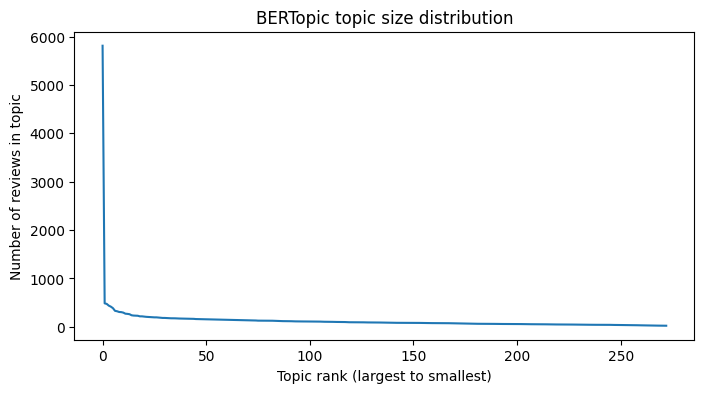

Topics with 100+ reviews: 115
Topics with 50+ reviews: 217


In [ ]:
import matplotlib.pyplot as plt

topic_sizes = topic_info[topic_info['Topic'] != -1]['Count'].values

plt.figure(figsize=(8,4))
plt.plot(sorted(topic_sizes, reverse=True))
plt.xlabel("Topic rank (largest to smallest)")
plt.ylabel("Number of reviews in topic")
plt.title("BERTopic topic size distribution")
plt.show()

print("Topics with 100+ reviews:", (topic_sizes >= 100).sum())
print("Topics with 50+ reviews:", (topic_sizes >= 50).sum())

Topics with 100+ reviews: 115
Topics with 50+ reviews: 217
Topics with 30+ reviews: 261


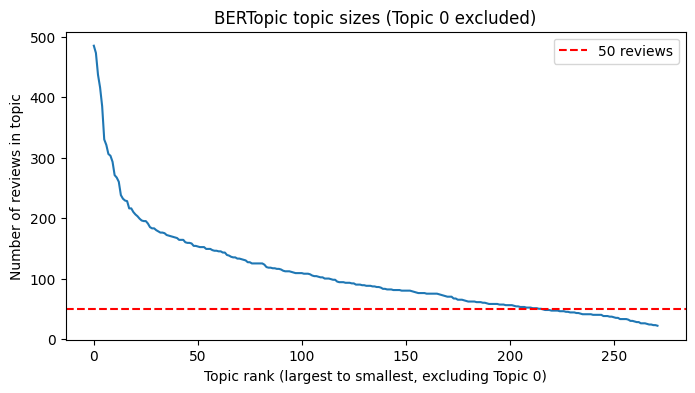

In [ ]:
print("Topics with 100+ reviews:", (topic_sizes >= 100).sum())
print("Topics with 50+ reviews:", (topic_sizes >= 50).sum())
print("Topics with 30+ reviews:", (topic_sizes >= 30).sum())

plt.figure(figsize=(8,4))
plt.plot(sorted(topic_sizes, reverse=True)[1:])
plt.xlabel("Topic rank (largest to smallest, excluding Topic 0)")
plt.ylabel("Number of reviews in topic")
plt.title("BERTopic topic sizes (Topic 0 excluded)")
plt.axhline(y=50, color='r', linestyle='--', label='50 reviews')
plt.legend()
plt.show()

In [ ]:
topic_model.reduce_topics(docs, nr_topics=20)

reduced_info = topic_model.get_topic_info()
print(reduced_info)

2026-07-29 15:48:44,760 - BERTopic - Topic reduction - Reducing number of topics
2026-07-29 15:48:44,831 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-29 15:48:45,102 - BERTopic - Representation - Completed ✓
2026-07-29 15:48:45,107 - BERTopic - Topic reduction - Reduced number of topics from 274 to 20


    Topic  Count  \
0      -1      4   
1       0  13744   
2       1   6019   
3       2   4625   
4       3   3540   
5       4   2532   
6       5   1247   
7       6    761   
8       7    587   
9       8    260   
10      9    237   
11     10    211   
12     11    186   
13     12    178   
14     13    171   
15     14    113   
16     15     80   
17     16     46   
18     17     41   
19     18     37   

                                                                               Name  \
0   -1_loooovvvvveeee_asesome_scribe_reallllllllllllllllllllllllllllllllllllllll...   
1                                                          0_tablet_kindle_not_read   
2                                                          1_echo_alexa_music_sound   
3                                                               2_love_gift_buy_old   
4                                                             3_tv_fire_stick_cable   
5                                                     4_p

In [ ]:
pd.set_option('display.max_rows', None)
print(reduced_info[['Topic', 'Count', 'Name']])

    Topic  Count  \
0      -1      4   
1       0  13744   
2       1   6019   
3       2   4625   
4       3   3540   
5       4   2532   
6       5   1247   
7       6    761   
8       7    587   
9       8    260   
10      9    237   
11     10    211   
12     11    186   
13     12    178   
14     13    171   
15     14    113   
16     15     80   
17     16     46   
18     17     41   
19     18     37   

                                                                               Name  
0   -1_loooovvvvveeee_asesome_scribe_reallllllllllllllllllllllllllllllllllllllll...  
1                                                          0_tablet_kindle_not_read  
2                                                          1_echo_alexa_music_sound  
3                                                               2_love_gift_buy_old  
4                                                             3_tv_fire_stick_cable  
5                                                     4_product

In [ ]:
for _, row in reduced_info.iterrows():
    print(f"Topic {row['Topic']:>3} | Count: {row['Count']:>5} | {row['Name']}")

Topic  -1 | Count:     4 | -1_loooovvvvveeee_asesome_scribe_reallllllllllllllllllllllllllllllllllllllllllllllly
Topic   0 | Count: 13744 | 0_tablet_kindle_not_read
Topic   1 | Count:  6019 | 1_echo_alexa_music_sound
Topic   2 | Count:  4625 | 2_love_gift_buy_old
Topic   3 | Count:  3540 | 3_tv_fire_stick_cable
Topic   4 | Count:  2532 | 4_product_great_buy_recommend
Topic   5 | Count:  1247 | 5_camera_read_picture_light
Topic   6 | Count:   761 | 6_carry_travel_purse_size
Topic   7 | Count:   587 | 7_set_table_easy_learn
Topic   8 | Count:   260 | 8_ad_advertise_annoying_not
Topic   9 | Count:   237 | 9_charge_charger_plug_fast
Topic  10 | Count:   211 | 10_expect_expectation_exceed_meet
Topic  11 | Count:   186 | 11_navigate_easy_tablet_use
Topic  12 | Count:   178 | 12_job_work_suppose_line
Topic  13 | Count:   171 | 13_version_warranty_model_upgrade
Topic  14 | Count:   113 | 14_thank_buy_good_product
Topic  15 | Count:    80 | 15_answer_question_ask_not
Topic  16 | Count:    46 | 1

In [ ]:
# Reset by refitting fresh, since reduce_topics is applied cumulatively otherwise
topic_model2 = BERTopic(language="english", calculate_probabilities=False, verbose=False)
topics2, _ = topic_model2.fit_transform(docs)
new_topics2 = topic_model2.reduce_outliers(docs, topics2, strategy="c-tf-idf")
topic_model2.update_topics(docs, topics=new_topics2)

topic_model2.reduce_topics(docs, nr_topics=35)

reduced_info2 = topic_model2.get_topic_info()
for _, row in reduced_info2.iterrows():
    print(f"Topic {row['Topic']:>3} | Count: {row['Count']:>5} | {row['Name']}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-07-29 19:11:28,511 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Topic  -1 | Count:     7 | -1_bueno_excelente_muy_asesome
Topic   0 | Count: 10007 | 0_tablet_kindle_not_read
Topic   1 | Count:  9308 | 1_echo_alexa_music_tv
Topic   2 | Count:  3561 | 2_gift_love_buy_christmas
Topic   3 | Count:  1866 | 3_kid_game_parental_case
Topic   4 | Count:  1717 | 4_read_book_reader_light
Topic   5 | Count:  1270 | 5_product_best_recommend_buy
Topic   6 | Count:   562 | 6_movie_watch_show_entertainment
Topic   7 | Count:   514 | 7_set_easy_setup_install
Topic   8 | Count:   492 | 8_slow_freeze_buffering_lag
Topic   9 | Count:   469 | 9_picture_clear_camera_screen
Topic  10 | Count:   465 | 10_box_stick_firestick_android
Topic  11 | Count:   443 | 11_job_work_upload_no
Topic  12 | Count:   393 | 12_purse_fit_size_small
Topic  13 | Count:   382 | 13_travel_carry_portable_easy
Topic  14 | Count:   368 | 14_technology_device_gadget_school
Topic  15 | Count:   317 | 15_wifi_ethernet_connect_wi
Topic  16 | Count:   300 | 16_friend_recommend_family_product
Topic  17 

In [ ]:
df_topics['bertopic_topic'] = topic_model2.get_document_info(docs)['Topic'].values
df_topics['bertopic_topic_name'] = topic_model2.get_document_info(docs)['Name'].values

df_topics.to_csv("../data/reviews_with_topics.csv", index=False)
print("Saved!")

Saved!


In [ ]:
# Cross-tab: topic vs sentiment, normalized by row (percentage within each topic)
topic_sentiment = pd.crosstab(
    df_topics['bertopic_topic_name'], 
    df_topics['sentiment'], 
    normalize='index'
) * 100

# Only look at topics with a meaningful sample size (skip tiny/outlier ones)
topic_counts = df_topics['bertopic_topic_name'].value_counts()
meaningful_topics = topic_counts[topic_counts >= 50].index
topic_sentiment_filtered = topic_sentiment.loc[meaningful_topics]

# Sort by highest % negative — the topics most worth business attention
topic_sentiment_sorted = topic_sentiment_filtered.sort_values('negative', ascending=False)
print(topic_sentiment_sorted.round(1))

sentiment                             negative  neutral  positive
bertopic_topic_name                                              
8_slow_freeze_buffering_lag               14.0     15.4      70.5
15_wifi_ethernet_connect_wi               11.0      7.9      81.1
17_ad_advertise_annoying_lock             10.9     12.8      76.2
24_charge_charger_hold_port               10.6      9.4      80.0
28_answer_question_ask_correct             7.0     16.9      76.1
29_plug_usb_drive_work                     6.6      8.2      85.2
23_warranty_version_upgrade_model          5.0      6.2      88.8
19_expect_expectation_exceed_product       3.6      5.7      90.7
30_pad_not_kid_buy                         3.6      7.1      89.3
11_job_work_upload_no                      3.4      9.5      87.1
18_navigate_easy_use_tablet                3.0      3.6      93.4
9_picture_clear_camera_screen              3.0      6.6      90.4
14_technology_device_gadget_school         2.7      4.3      92.9
20_table_f

Top 10 Topics With Negative Sentiment Share

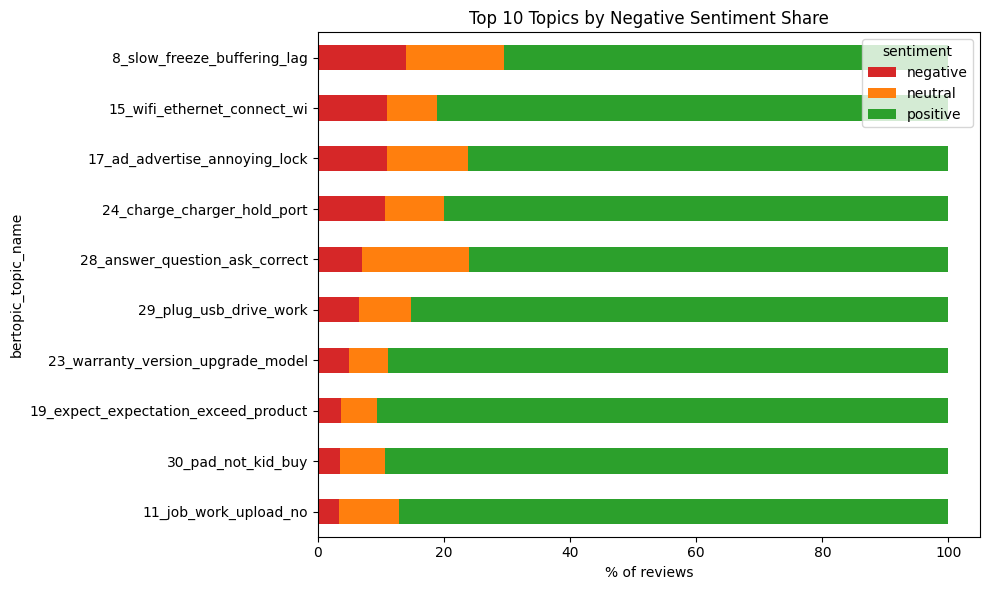

In [ ]:
import matplotlib.pyplot as plt

top_negative = topic_sentiment_sorted.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_negative[['negative', 'neutral', 'positive']].plot(
    kind='barh', stacked=True, ax=ax, color=['#d62728', '#ff7f0e', '#2ca02c']
)
ax.set_xlabel('% of reviews')
ax.set_title('Top 10 Topics by Negative Sentiment Share')
ax.invert_yaxis()  # highest negative % at top
plt.tight_layout()
plt.show()

sentiment    negative  neutral  positive
review_year                             
2015.0           17.8     24.4      57.8
2016.0           15.8     12.0      72.2
2017.0           10.5     18.2      71.3


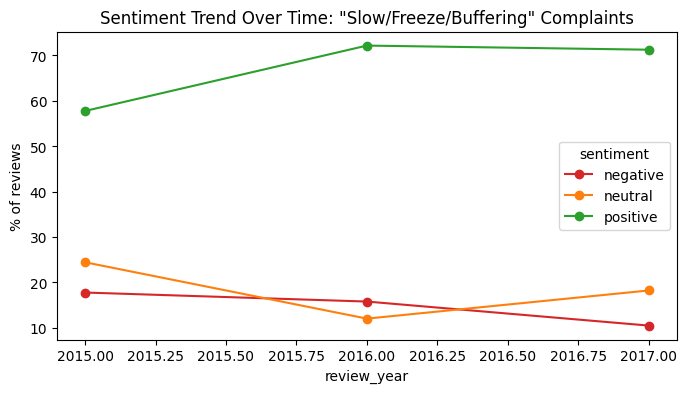

In [ ]:
df_topics['review_year'] = pd.to_datetime(df_topics['reviews.date'], errors='coerce').dt.year

# Focus on the worst offender topic
buffering_over_time = df_topics[df_topics['bertopic_topic_name'] == '8_slow_freeze_buffering_lag']
yearly_sentiment = pd.crosstab(buffering_over_time['review_year'], buffering_over_time['sentiment'], normalize='index') * 100

print(yearly_sentiment.round(1))

yearly_sentiment.plot(kind='line', marker='o', figsize=(8,4), color=['#d62728', '#ff7f0e', '#2ca02c'])
plt.title('Sentiment Trend Over Time: "Slow/Freeze/Buffering" Complaints')
plt.ylabel('% of reviews')
plt.show()

In [ ]:
print(buffering_over_time['review_year'].value_counts().sort_index())

review_year
2015.0     45
2016.0    266
2017.0    181
Name: count, dtype: int64


In [1]:
import pandas as pd
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import os

In [2]:
df_topics = pd.read_csv("../data/reviews_with_topics.csv", low_memory=False)
df_topics['tokens'] = df_topics['cleaned_text'].apply(lambda x: str(x).split())
print(df_topics.shape)
print(df_topics.columns.tolist())

(34619, 28)
['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'review.date', 'review_word_count', 'cleaned_text', 'sentiment', 'tokens', 'bertopic_topic', 'bertopic_topic_name']


In [ ]:
dictionary = corpora.Dictionary(df_topics['tokens'])
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(tokens) for tokens in df_topics['tokens']]

lda_final = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=4,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

for idx, topic in lda_final.print_topics(num_words=10):
    print(f"Topic {idx}: {topic}\n")

Topic 0: 0.087*"great" + 0.071*"love" + 0.058*"use" + 0.054*"easy" + 0.044*"buy" + 0.035*"product" + 0.028*"good" + 0.024*"tablet" + 0.022*"recommend" + 0.020*"purchase"

Topic 1: 0.050*"alexa" + 0.049*"echo" + 0.044*"music" + 0.025*"home" + 0.023*"voice" + 0.019*"ask" + 0.018*"play" + 0.018*"speaker" + 0.017*"sound" + 0.014*"question"

Topic 2: 0.069*"kindle" + 0.048*"read" + 0.030*"book" + 0.023*"screen" + 0.021*"light" + 0.016*"battery" + 0.016*"not" + 0.014*"cover" + 0.013*"charge" + 0.012*"like"

Topic 3: 0.045*"not" + 0.044*"tv" + 0.036*"fire" + 0.035*"amazon" + 0.018*"work" + 0.017*"app" + 0.016*"device" + 0.013*"box" + 0.012*"stick" + 0.012*"fast"



In [ ]:
os.makedirs("../outputs", exist_ok=True)

vis = gensimvis.prepare(lda_final, corpus, dictionary)
pyLDAvis.save_html(vis, '../outputs/lda_visualization.html')
print("Saved!")

Saved!


In [3]:
from sentence_transformers import SentenceTransformer

In [4]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

texts = df_topics['cleaned_text'].fillna('').tolist()

embeddings = embed_model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/541 [00:00<?, ?it/s]

Embeddings shape: (34619, 384)


In [6]:
import faiss
import numpy as np

dimension = embeddings.shape[1]  # 384

# IndexFlatIP = exact search using inner product (dot product).
# We normalize vectors first so inner product = cosine similarity.
faiss.normalize_L2(embeddings)

index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print("Number of vectors in index:", index.ntotal)

# Save the index to disk so we don't have to re-embed every time
faiss.write_index(index, "../data/reviews_faiss.index")
print("Saved!")

Number of vectors in index: 34619
Saved!


In [7]:
def semantic_search(query, k=5):
    """Search reviews by meaning, not keywords. Returns top-k most similar reviews."""
    # Embed the query the same way we embedded the reviews
    query_vec = embed_model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_vec)  # must normalize the same way as the index

    # Search the index: returns similarity scores and row positions
    scores, indices = index.search(query_vec, k)

    # Map row positions back to actual review text + metadata
    results = df_topics.iloc[indices[0]].copy()
    results['similarity_score'] = scores[0]

    return results[['reviews.text', 'sentiment', 'bertopic_topic_name', 'similarity_score']]

# Try it out
results = semantic_search("screen freezes and stops responding")
print(results.to_string())

                                                                                                                                                                                                                                                                                                          reviews.text sentiment          bertopic_topic_name  similarity_score
663                                                                                                                                                                                                                                                       Freeze frequently... No way to trouble shoot or repair it...  negative  8_slow_freeze_buffering_lag          0.613299
8952   From the first time I used it, the pages kept freezing and didn't respond to touch commands. I had to turn it off and back on daily. I tried to get a replacement and was told they no longer have them and I'd have to pay $10. more for a newer model. I bought

In [8]:
# Different topic entirely — should land in a different cluster, not the freeze one
print(semantic_search("battery drains too fast").to_string())

# Paraphrased query with none of the original words — tests true semantic matching
print(semantic_search("arrived broken right out of the box").to_string())

                                                                              reviews.text sentiment          bertopic_topic_name  similarity_score
9463   Battery seems to drain quickly. Otherwise very happy with this device! Great price!  positive     0_tablet_kindle_not_read          0.673923
15197                            battery seems to die fast, but that is my only complaint.  positive     0_tablet_kindle_not_read          0.646680
16678              It was too slow he didn't put any attention to it. Battery didn't last.  negative  8_slow_freeze_buffering_lag          0.626423
21485                           The battery life is amazing and quickly gets a full charge  positive     0_tablet_kindle_not_read          0.622687
15442                                  Does everything I need and has a long battery life.  positive     0_tablet_kindle_not_read          0.609575
                                                                                                                

In [9]:
print(semantic_search("good tablet for young children").to_string())

                                                             reviews.text sentiment       bertopic_topic_name  similarity_score
7931                   Great simple tablet for younger children to use...  positive  0_tablet_kindle_not_read          0.896043
11024        Great tablet for the beginner or young child. would recomend  positive  0_tablet_kindle_not_read          0.886856
4873                 Great Tablet. Its Easy to use and it's kid friendly.  positive  0_tablet_kindle_not_read          0.857880
15371                 It's a very good tablet for your child everyday use  positive  0_tablet_kindle_not_read          0.853383
13407  Good for kids And adults. I would recommend this tablet to anyone.  positive  0_tablet_kindle_not_read          0.849227
